# 03 — Neural ODE Autoencoder: Architecture

This notebook documents the Neural ODE Autoencoder architecture for unsupervised DDoS detection. We walk through each component with mathematical formulations, shape annotations, and code demonstrations.

**Architecture overview:**
```
x ∈ ℝ^{B×50×49}  →  [BiGRU Encoder]  →  z₀ ∈ ℝ^{B×32}  →  [Neural ODE]  →  z₁ ∈ ℝ^{B×32}  →  [MLP Decoder]  →  x̂ ∈ ℝ^{B×50×49}
```

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn as nn
import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torchdiffeq import odeint

from src.model import BiGRUEncoder, ODEFunc, MLPDecoder, NeuralODEAutoencoder
from src.dataset import FlowWindowDataset

with open('../configs/default.yaml') as f:
    config = yaml.safe_load(f)

torch.manual_seed(42)
print(f'PyTorch {torch.__version__}')

PyTorch 2.11.0


## 1. Architecture Diagram

The following diagram shows the complete data flow through the model, with tensor shapes annotated at each stage.

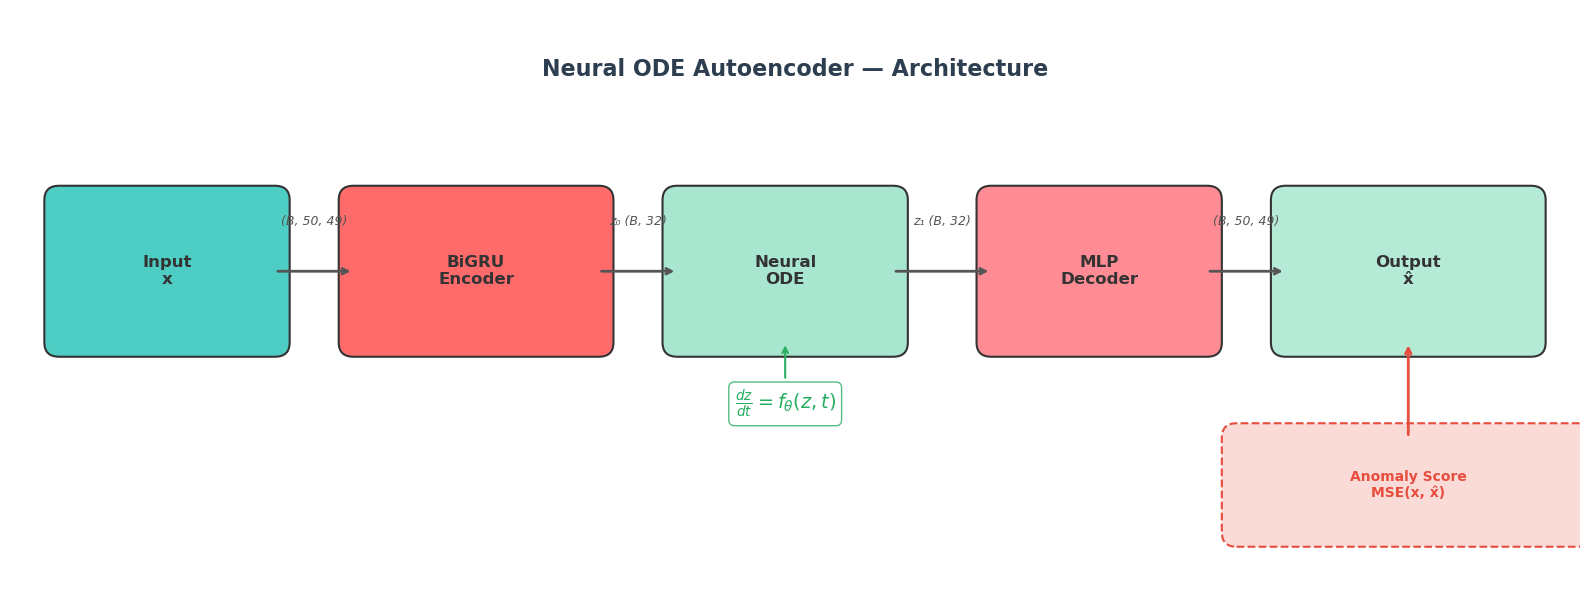

Saved to figures/architecture_diagram.png


In [2]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.set_xlim(0, 16)
ax.set_ylim(0, 6)
ax.axis('off')

# Color scheme
colors = {
    'input': '#4ECDC4',
    'encoder': '#FF6B6B',
    'latent': '#FFE66D',
    'ode': '#A8E6CF',
    'decoder': '#FF8B94',
    'output': '#B5EAD7',
}

# Boxes
boxes = [
    (0.5, 2.5, 2.2, 1.5, 'Input\nx', colors['input']),
    (3.5, 2.5, 2.5, 1.5, 'BiGRU\nEncoder', colors['encoder']),
    (6.8, 2.5, 2.2, 1.5, 'Neural\nODE', colors['ode']),
    (10.0, 2.5, 2.2, 1.5, 'MLP\nDecoder', colors['decoder']),
    (13.0, 2.5, 2.5, 1.5, 'Output\nx\u0302', colors['output']),
]

for x, y, w, h, text, color in boxes:
    rect = mpatches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle='round,pad=0.15',
        facecolor=color, edgecolor='#333333', linewidth=1.5
    )
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text,
            ha='center', va='center', fontsize=12, fontweight='bold', color='#333333')

# Arrows with shape annotations
arrows = [
    (2.7, 3.25, 3.5, 3.25, '(B, 50, 49)'),
    (6.0, 3.25, 6.8, 3.25, 'z\u2080 (B, 32)'),
    (9.0, 3.25, 10.0, 3.25, 'z\u2081 (B, 32)'),
    (12.2, 3.25, 13.0, 3.25, '(B, 50, 49)'),
]

for x1, y1, x2, y2, label in arrows:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', lw=2, color='#555555'))
    ax.text((x1 + x2)/2, y1 + 0.45, label,
            ha='center', va='bottom', fontsize=9, fontstyle='italic', color='#555555')

# Anomaly score path
ax.annotate('', xy=(14.25, 2.5), xytext=(14.25, 1.5),
            arrowprops=dict(arrowstyle='->', lw=2, color='#E74C3C'))
rect = mpatches.FancyBboxPatch(
    (12.5, 0.5), 3.5, 1.0,
    boxstyle='round,pad=0.15',
    facecolor='#FADBD8', edgecolor='#E74C3C', linewidth=1.5, linestyle='--'
)
ax.add_patch(rect)
ax.text(14.25, 1.0, 'Anomaly Score\nMSE(x, x\u0302)', 
        ha='center', va='center', fontsize=10, color='#E74C3C', fontweight='bold')

# Title
ax.text(8, 5.3, 'Neural ODE Autoencoder — Architecture',
        ha='center', fontsize=16, fontweight='bold', color='#2C3E50')

# ODE annotation
ax.text(7.9, 1.8, r'$\frac{dz}{dt} = f_\theta(z, t)$',
        ha='center', fontsize=14, color='#27AE60',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#27AE60', alpha=0.8))
ax.annotate('', xy=(7.9, 2.5), xytext=(7.9, 2.1),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='#27AE60'))

plt.tight_layout()
plt.savefig('../figures/architecture_diagram.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved to figures/architecture_diagram.png')

## 2. BiGRU Encoder

The encoder maps a sequence of 50 network flow vectors into a single latent vector $z_0 \in \mathbb{R}^{32}$.

### GRU Gate Equations

At each time step $t$, the GRU computes:

$$
\begin{align}
r_t &= \sigma(W_r x_t + U_r h_{t-1} + b_r) & \text{(reset gate)} \\
z_t &= \sigma(W_z x_t + U_z h_{t-1} + b_z) & \text{(update gate)} \\
\tilde{h}_t &= \tanh(W_h x_t + U_h (r_t \odot h_{t-1}) + b_h) & \text{(candidate)} \\
h_t &= (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t & \text{(hidden state)}
\end{align}
$$

where $\sigma$ is the sigmoid function, $\odot$ denotes element-wise multiplication.

### Bidirectional Architecture

A **bidirectional** GRU processes the sequence in both directions:

$$
\overrightarrow{h_t} = \text{GRU}_{\text{fwd}}(x_t, \overrightarrow{h_{t-1}}) \qquad \overleftarrow{h_t} = \text{GRU}_{\text{bwd}}(x_t, \overleftarrow{h_{t+1}})
$$

The final hidden states from both directions are concatenated and projected:

$$
z_0 = W_p \left[ \overrightarrow{h_T} \| \overleftarrow{h_1} \right] + b_p \quad \in \mathbb{R}^{32}
$$

**Configuration:** 2 layers, hidden size 128 per direction.

| Stage | Shape | Description |
|-------|-------|-------------|
| Input | `(B, 50, 49)` | Window of 50 flows, 49 features each |
| GRU output | `(B, 50, 256)` | 128 per direction × 2 |
| Final hidden | `(B, 256)` | Last fwd + last bwd hidden states |
| Projection | `(B, 32)` | Linear layer to latent dimension |

In [3]:
# Instantiate encoder and trace shapes
encoder = BiGRUEncoder(input_dim=49, hidden_size=128, num_layers=2, latent_dim=32)

x = torch.randn(4, 50, 49)  # batch of 4 windows
z0 = encoder(x)

print(f'Input shape:       {x.shape}       — (batch, seq_len, features)')
print(f'Latent z₀ shape:   {z0.shape}        — (batch, latent_dim)')

# Detailed trace
output, h_n = encoder.gru(x)
print(f'\nGRU output shape:  {output.shape}  — (batch, seq_len, 2×hidden_size)')
print(f'GRU h_n shape:     {h_n.shape}     — (num_layers×2, batch, hidden_size)')
print(f'h_n[-2] (fwd):     {h_n[-2].shape}       — last layer forward')
print(f'h_n[-1] (bwd):     {h_n[-1].shape}       — last layer backward')

n_params = sum(p.numel() for p in encoder.parameters())
print(f'\nEncoder parameters: {n_params:,}')

Input shape:       torch.Size([4, 50, 49])       — (batch, seq_len, features)
Latent z₀ shape:   torch.Size([4, 32])        — (batch, latent_dim)

GRU output shape:  torch.Size([4, 50, 256])  — (batch, seq_len, 2×hidden_size)
GRU h_n shape:     torch.Size([4, 4, 128])     — (num_layers×2, batch, hidden_size)
h_n[-2] (fwd):     torch.Size([4, 128])       — last layer forward
h_n[-1] (bwd):     torch.Size([4, 128])       — last layer backward

Encoder parameters: 442,144


## 3. Neural ODE

### Continuous-Time Dynamics

Instead of discrete transformation layers, a Neural ODE defines the latent state evolution as a continuous dynamical system:

$$
\frac{dz}{dt} = f_\theta(z(t), t)
$$

where $f_\theta$ is a neural network that parameterizes the vector field. The latent state at time $T$ is obtained by integrating this ODE:

$$
z_1 = z_0 + \int_0^T f_\theta(z(t), t) \, dt
$$

### Why Neural ODE for Anomaly Detection?

The key insight is that **the ODE learns the continuous dynamics of normal (benign) traffic** in latent space. When the model encounters attack traffic:

1. The encoder maps it to a latent code $z_0$ that lies in an unfamiliar region
2. The ODE evolves $z_0$ according to **benign dynamics**, producing a $z_1$ that reflects normal traffic patterns
3. The decoder reconstructs a "benign-like" window from $z_1$
4. The mismatch between the original attack window and the benign reconstruction yields high MSE

### Dynamics Network $f_\theta$

The dynamics function is an MLP that takes the concatenation of the latent state and time:

$$
f_\theta(z, t) = W_3 \cdot \text{SiLU}(W_2 \cdot \text{SiLU}(W_1 [z \| t] + b_1) + b_2) + b_3
$$

where $[z \| t]$ denotes concatenation ($\mathbb{R}^{33}$), and SiLU (Sigmoid Linear Unit) is:

$$
\text{SiLU}(x) = x \cdot \sigma(x)
$$

### Dormand-Prince Solver (dopri5)

We use the **Dormand-Prince** method (a 5th-order Runge-Kutta method with adaptive step sizing):
- Automatically adjusts step size based on local error estimates
- Takes larger steps in smooth regions, smaller steps where dynamics change rapidly
- Controlled by tolerances: `atol=1e-5`, `rtol=1e-5`
- Integration interval: $t \in [0, 1]$

| Stage | Shape | Description |
|-------|-------|-------------|
| Input $z_0$ | `(B, 32)` | Initial latent state from encoder |
| $[z \| t]$ | `(B, 33)` | Time-augmented state |
| $f_\theta$ output | `(B, 32)` | Velocity $dz/dt$ |
| Output $z_1$ | `(B, 32)` | Evolved latent state at $t=1$ |

In [4]:
# Instantiate ODE dynamics and demonstrate integration
ode_func = ODEFunc(latent_dim=32, hidden_size=128)

z0_sample = torch.randn(4, 32)  # batch of 4 latent vectors
t_span = torch.tensor([0.0, 1.0])

# Single evaluation of the dynamics
dz_dt = ode_func(torch.tensor(0.0), z0_sample)
print(f'z₀ shape:     {z0_sample.shape}  — initial latent state')
print(f'dz/dt shape:  {dz_dt.shape}  — velocity at t=0')

# Full ODE integration
z_trajectory = odeint(ode_func, z0_sample, t_span, method='dopri5', atol=1e-5, rtol=1e-5)
print(f'\nTrajectory shape: {z_trajectory.shape}  — (time_points, batch, latent_dim)')
print(f'z₀ = z_trajectory[0]:  same as input')
print(f'z₁ = z_trajectory[-1]: evolved state at t=1')

n_params = sum(p.numel() for p in ode_func.parameters())
print(f'\nODE function parameters: {n_params:,}')

z₀ shape:     torch.Size([4, 32])  — initial latent state
dz/dt shape:  torch.Size([4, 32])  — velocity at t=0

Trajectory shape: torch.Size([2, 4, 32])  — (time_points, batch, latent_dim)
z₀ = z_trajectory[0]:  same as input
z₁ = z_trajectory[-1]: evolved state at t=1

ODE function parameters: 24,992


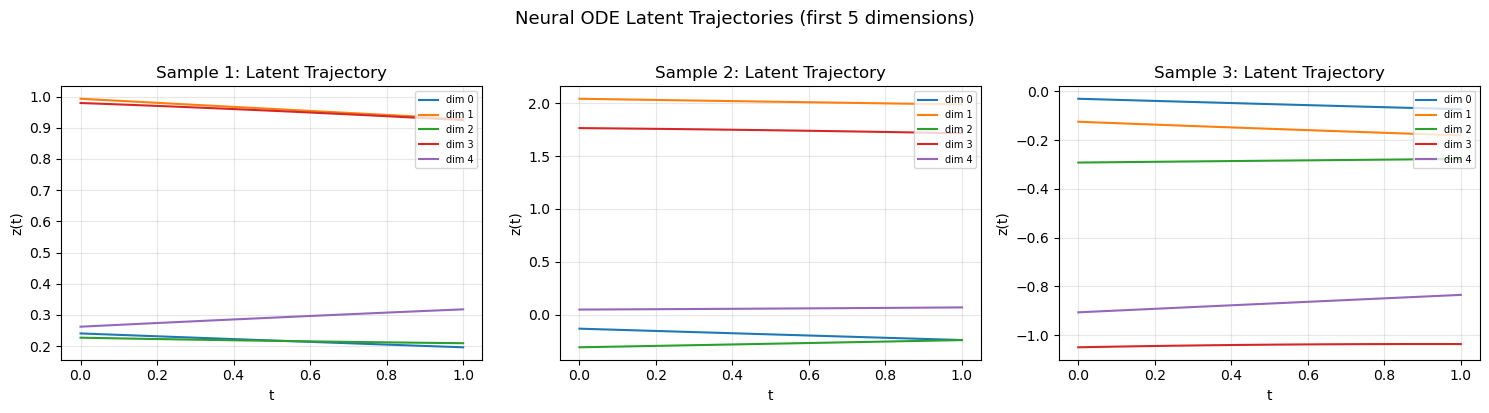

In [5]:
# Visualize latent trajectories for 3 sample windows
# We integrate with many time points to see the full trajectory
t_fine = torch.linspace(0, 1, 50)

with torch.no_grad():
    z_traj = odeint(ode_func, z0_sample[:3], t_fine, method='dopri5', atol=1e-5, rtol=1e-5)
    # z_traj: (50, 3, 32)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, ax in enumerate(axes):
    # Plot first 5 latent dimensions over time
    for d in range(5):
        ax.plot(t_fine.numpy(), z_traj[:, i, d].numpy(), lw=1.5, label=f'dim {d}')
    ax.set_xlabel('t')
    ax.set_ylabel('z(t)')
    ax.set_title(f'Sample {i+1}: Latent Trajectory')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

fig.suptitle('Neural ODE Latent Trajectories (first 5 dimensions)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/latent_trajectories.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 4. MLP Decoder

The decoder maps the evolved latent vector $z_1$ back to the original input space:

$$
\hat{x} = \text{reshape}\left( W_3 \cdot \text{SiLU}(W_2 \cdot \text{SiLU}(W_1 z_1 + b_1) + b_2) + b_3, \quad (50, 49) \right)
$$

**No output activation** — the targets are RobustScaler-transformed features with unbounded range. Any activation function (sigmoid, tanh) would clip the output and prevent accurate reconstruction of extreme values.

| Stage | Shape | Description |
|-------|-------|-------------|
| Input $z_1$ | `(B, 32)` | Evolved latent state |
| Hidden 1 | `(B, 128)` | Linear + SiLU |
| Hidden 2 | `(B, 128)` | Linear + SiLU |
| Output (flat) | `(B, 2450)` | 50 × 49 features |
| Reshape | `(B, 50, 49)` | Reconstructed window |

In [6]:
decoder = MLPDecoder(latent_dim=32, hidden_size=128, seq_len=50, input_dim=49)

z1_sample = torch.randn(4, 32)
x_hat = decoder(z1_sample)

print(f'z₁ shape:     {z1_sample.shape}   — input to decoder')
print(f'x̂ shape:      {x_hat.shape}  — reconstructed window')
print(f'Output range:  [{x_hat.min():.2f}, {x_hat.max():.2f}]  — no activation, unbounded')

n_params = sum(p.numel() for p in decoder.parameters())
print(f'\nDecoder parameters: {n_params:,}')

z₁ shape:     torch.Size([4, 32])   — input to decoder
x̂ shape:      torch.Size([4, 50, 49])  — reconstructed window
Output range:  [-0.30, 0.29]  — no activation, unbounded

Decoder parameters: 336,786


## 5. Full Pipeline

### End-to-End Data Flow

$$
x \in \mathbb{R}^{B \times 50 \times 49} \xrightarrow{\text{BiGRU}} z_0 \in \mathbb{R}^{B \times 32} \xrightarrow{\text{ODE}} z_1 \in \mathbb{R}^{B \times 32} \xrightarrow{\text{MLP}} \hat{x} \in \mathbb{R}^{B \times 50 \times 49}
$$

### Loss Function

The model is trained to minimize the **mean squared error** between input and reconstruction:

$$
\mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} \frac{1}{T \cdot D} \| x_i - \hat{x}_i \|_F^2
$$

where $N$ is the batch size, $T = 50$ is the sequence length, $D = 49$ is the feature dimension, and $\| \cdot \|_F$ is the Frobenius norm.

### Anomaly Score

At inference time, the **per-window anomaly score** is the mean squared reconstruction error:

$$
\text{score}(x) = \frac{1}{T \cdot D} \| x - \hat{x} \|_F^2
$$

Windows with score above a threshold $\tau$ (tuned on validation set to maximize F1) are flagged as anomalous.

In [7]:
# Full forward pass with the complete model
model = NeuralODEAutoencoder(config)

# Load a real batch from the processed data
dataset = FlowWindowDataset('../data/processed', 'val')
x_real, y_real = dataset[0:8]  # 8 windows
# Use DataLoader for proper batching
from torch.utils.data import DataLoader
loader = DataLoader(dataset, batch_size=8, shuffle=False)
x_batch, y_batch = next(iter(loader))

print(f'Input batch:  {x_batch.shape}  labels: {y_batch.tolist()}')

with torch.no_grad():
    x_hat, z0 = model(x_batch)
    scores = model.anomaly_score(x_batch)

print(f'Output batch: {x_hat.shape}')
print(f'Latent z₀:    {z0.shape}')
print(f'Anomaly scores: {scores.numpy().round(4)}')
print(f'Labels:         {y_batch.numpy()}')
print(f'\nNote: scores are random before training — no separation expected yet.')

Input batch:  torch.Size([8, 50, 49])  labels: [0, 1, 0, 1, 0, 0, 1, 0]
Output batch: torch.Size([8, 50, 49])
Latent z₀:    torch.Size([8, 32])
Anomaly scores: [1.2276935e+13 7.8311210e+12 1.0944640e+13 2.5383362e+12 8.9990491e+12
 9.2846728e+12 6.5830031e+12 1.1849810e+13]
Labels:         [0 1 0 1 0 0 1 0]

Note: scores are random before training — no separation expected yet.


## 6. Parameter Count

A detailed breakdown of learnable parameters per submodule.

In [8]:
# Make sure model is initialized
with torch.no_grad():
    dummy = torch.randn(1, 50, 49)
    _ = model(dummy)

def count_params(module):
    return sum(p.numel() for p in module.parameters())

components = [
    ('BiGRU Encoder', model.encoder),
    ('  └─ GRU layers', model.encoder.gru),
    ('  └─ Projection', model.encoder.projection),
    ('ODE Dynamics fθ', model.ode_func),
    ('MLP Decoder', model.decoder),
]

print(f'{"Component":<25} {"Parameters":>12}')
print('─' * 38)
for name, module in components:
    print(f'{name:<25} {count_params(module):>12,}')
print('─' * 38)
total = count_params(model)
print(f'{"TOTAL":<25} {total:>12,}')
print(f'\nModel size: ~{total * 4 / 1024 / 1024:.1f} MB (float32)')

Component                   Parameters
──────────────────────────────────────
BiGRU Encoder                  442,144
  └─ GRU layers                433,920
  └─ Projection                  8,224
ODE Dynamics fθ                 24,992
MLP Decoder                    336,786
──────────────────────────────────────
TOTAL                          803,922

Model size: ~3.1 MB (float32)


## 7. Training Strategy

### Unsupervised Objective

The model is trained **entirely on benign traffic** — it never sees attack patterns during training. The training set contains only benign windows (69,918 windows). Labels are used **only** for evaluation, never for loss computation.

### Optimization

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Optimizer | Adam | Adaptive learning rates, standard for deep learning |
| Learning rate | $10^{-3}$ | Default Adam LR, works well for autoencoders |
| Weight decay | $10^{-5}$ | Light L2 regularization |
| Scheduler | Cosine Annealing | Smooth LR decay, avoids learning rate cliffs |
| Batch size | 256 | Balances gradient noise and memory |
| Early stopping | Patience 5 | Stop when benign val loss stops improving |

### Cosine Annealing Schedule

$$
\eta_t = \eta_{\min} + \frac{1}{2}(\eta_{\max} - \eta_{\min})\left(1 + \cos\left(\frac{t}{T}\pi\right)\right)
$$

### Validation

Validation loss is computed **only on benign windows** in the validation set. This ensures early stopping reflects the model's ability to reconstruct normal traffic, not its confusion on attacks.

## 8. Why Neural ODE?

### Advantages over discrete autoencoders

| Property | Standard AE / LSTM-AE | Neural ODE AE |
|----------|----------------------|---------------|
| **Latent transformation** | Fixed number of discrete layers | Continuous-time dynamics |
| **Computation** | Same for all inputs | Adaptive — dopri5 takes more steps for complex dynamics |
| **Latent trajectories** | Discrete jumps between layers | Smooth, physically interpretable trajectories |
| **Memory** | Proportional to depth | Constant (adjoint method, though not needed here) |
| **Expressiveness** | Limited by number of layers | Equivalent to infinite-depth ResNet |

### Connection to dynamical systems

Network traffic has inherent **temporal dynamics** — flow rates, packet sizes, and inter-arrival times evolve smoothly over time during normal operation. A Neural ODE is a natural fit because:

1. **Normal traffic** follows regular dynamics: the ODE learns a smooth vector field $f_\theta$ that captures benign patterns
2. **Attack traffic** creates discontinuities: DDoS floods produce latent codes that are far from the learned manifold
3. **The ODE "normalizes"** anomalous inputs: even when $z_0$ is in an unusual region, the ODE evolves it toward benign dynamics, creating a reconstruction that looks normal
4. **The reconstruction gap** between attack input and benign-like output is the anomaly signal

### ResNet ↔ Neural ODE analogy

A residual network computes:
$$h_{t+1} = h_t + f_\theta(h_t)$$

This is an **Euler discretization** of the ODE $dh/dt = f_\theta(h)$ with step size 1. A Neural ODE replaces the fixed-step Euler method with an adaptive solver, giving effectively infinite depth with continuous dynamics.

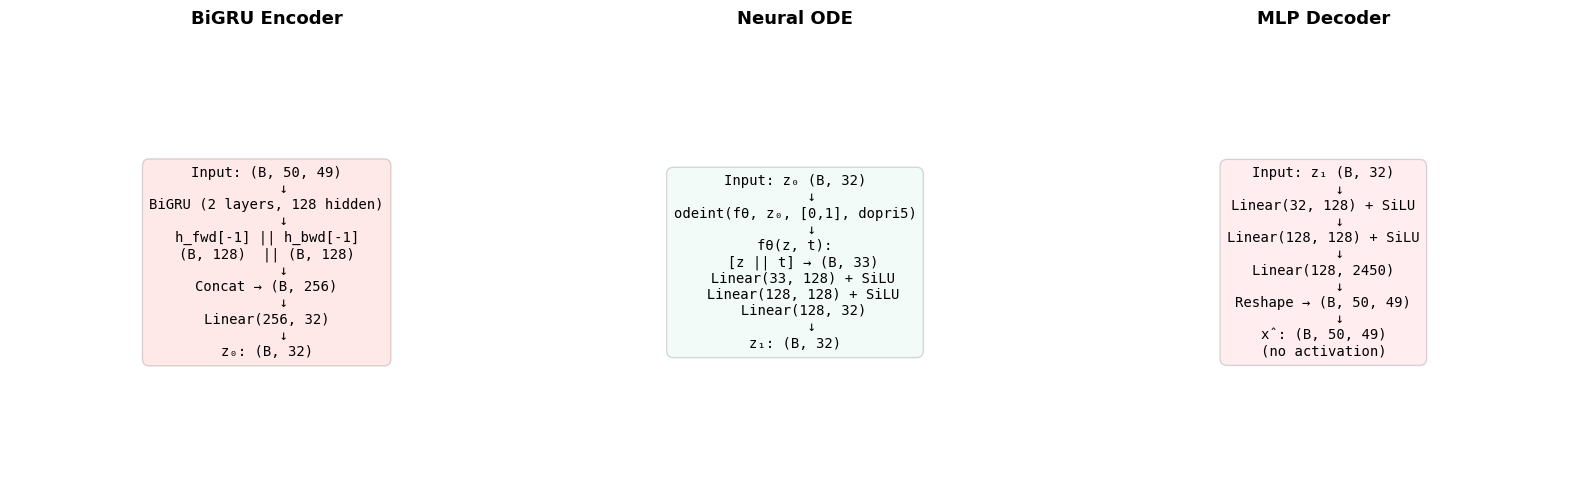

In [9]:
# Summary diagram: component details
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Encoder details
ax = axes[0]
ax.axis('off')
ax.set_title('BiGRU Encoder', fontsize=13, fontweight='bold', pad=15)
encoder_text = (
    'Input: (B, 50, 49)\n'
    '    ↓\n'
    'BiGRU (2 layers, 128 hidden)\n'
    '    ↓\n'
    'h_fwd[-1] || h_bwd[-1]\n'
    '(B, 128)  || (B, 128)\n'
    '    ↓\n'
    'Concat → (B, 256)\n'
    '    ↓\n'
    'Linear(256, 32)\n'
    '    ↓\n'
    'z₀: (B, 32)'
)
ax.text(0.5, 0.5, encoder_text, transform=ax.transAxes,
        fontsize=10, fontfamily='monospace', va='center', ha='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FF6B6B', alpha=0.15))

# ODE details
ax = axes[1]
ax.axis('off')
ax.set_title('Neural ODE', fontsize=13, fontweight='bold', pad=15)
ode_text = (
    'Input: z₀ (B, 32)\n'
    '    ↓\n'
    'odeint(fθ, z₀, [0,1], dopri5)\n'
    '    ↓\n'
    'fθ(z, t):\n'
    '  [z || t] → (B, 33)\n'
    '  Linear(33, 128) + SiLU\n'
    '  Linear(128, 128) + SiLU\n'
    '  Linear(128, 32)\n'
    '    ↓\n'
    'z₁: (B, 32)'
)
ax.text(0.5, 0.5, ode_text, transform=ax.transAxes,
        fontsize=10, fontfamily='monospace', va='center', ha='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#A8E6CF', alpha=0.15))

# Decoder details
ax = axes[2]
ax.axis('off')
ax.set_title('MLP Decoder', fontsize=13, fontweight='bold', pad=15)
decoder_text = (
    'Input: z₁ (B, 32)\n'
    '    ↓\n'
    'Linear(32, 128) + SiLU\n'
    '    ↓\n'
    'Linear(128, 128) + SiLU\n'
    '    ↓\n'
    'Linear(128, 2450)\n'
    '    ↓\n'
    'Reshape → (B, 50, 49)\n'
    '    ↓\n'
    'x̂: (B, 50, 49)\n'
    '(no activation)'
)
ax.text(0.5, 0.5, decoder_text, transform=ax.transAxes,
        fontsize=10, fontfamily='monospace', va='center', ha='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FF8B94', alpha=0.15))

plt.tight_layout()
plt.savefig('../figures/component_details.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()